# Safe Parking Need Analysis

*UP213 Urban Data Science (2025 Spring) Group Project*

#### **Group Members:** Simon Han, Tomohiro Ujikawa  

## Objective 
To identify where vehicle homelessness is concentrated in Los Angeles, and to assess underused parking garages that could help meet the need for safe overnight parking.

## Background  
Vehicle residency is on the rise among working-class individuals and families as housing costs continue to outpace wages in LA. While permanent housing remains the long-term goal, the shortage of affordable units and the time and cost required to build them has created an urgent need for **immediate, interim solutions**.

Safe parking programs, which provide a legal place to sleep in one’s vehicle along with access to restrooms and services, are one such solution. Many city-owned parking garages in LA sit largely empty during overnight hours and could be repurposed to support these programs. This project analyzes both the **concentration of vehicle homelessness** and the **potential of underused city-owned garages** to serve as safe parking sites.

## Key Questions  
- Where is **vehicle homelessness concentrated** in Los Angeles?  
- Which **underused parking garages** could be matched with areas of high need for safe parking?

#### **Dataset:**
Safe Parking **Needs**: 
- LAHSA Homeless Count: vehicle dwelling counts by tract
- ACS: poverty, rent burden, vehicle ownership, housing overcrowding

Potential **Supply**:  
- ParkMe (real-time occupancy data for Santa Monica)  
- City of LA Parking Garage Locations and Characteristics  
- Supplemental: Zoning, transit access, and service proximity (for refining site viability)

#### **Method:**
- **Data Scraping** for real-time or web-only garage data 
- **Spatial Joins** to overlay homelessness data with garage locations
- **Machine Learning** to predict unmet safe parking need using ACS features 
- **Overlay Analysis** to identify garage locations that could meet the predicted need

In [2]:
import os
import pandas as pd
import geopandas as gpd

os.getcwd()

'/Users/Tomo/Desktop/UP213_group'

### Tiger/Lines

##### Importing Tiger Lines & sorting LA county for 2020-24 years

In [3]:
for year in range(2019, 2025):
    path = f"Data/tl_shp_library/tl_{year}_06_tract.zip"
    tracts = gpd.read_file(path)
    la_tracts = tracts[(tracts["COUNTYFP"] == "037") & (tracts["STATEFP"] == "06")]
    la_tracts = la_tracts.set_index('GEOID')
    
    var_name = f"tracts{str(year)[-2:]}"
    globals()[var_name] = la_tracts

now we have Tiger/Line GDFs named (tracts19, tracts20, tracts21, .., tracts24)

##### checking the proportion of indentical data

In [4]:
#checking the proportion of indentical data between 2020 and 24
#getting index as set
index_20 = set(tracts20.index)
index_24 = set(tracts24.index)

#counting the shared GEOIDs
common_geoids = index_20 & index_24
num_common = len(common_geoids)

#counting the GEOID of each dataframe
num_2020 = len(index_20)
num_2024 = len(index_24)

#calculating the matching ratio
match_rate_2020 = num_common / num_2020
match_rate_2024 = num_common / num_2024
print(match_rate_2020)
print(match_rate_2024)

1.0
1.0


confirmed Tiger/line in 2020 and 24 have the same GEOIDs

In [5]:
#checking the proportion of indentical data between 2019 and 20
#getting index as set
index_19 = set(tracts19.index)
index_20 = set(tracts20.index)

#counting the shared GEOIDs
common_geoids = index_19 & index_20
num_common = len(common_geoids)

#counting the GEOID of each dataframe
num_2019 = len(index_19)
num_2020 = len(index_20)

#calculating the matching ratio
match_rate_2019 = num_common / num_2019
match_rate_2020 = num_common / num_2020
print(match_rate_2019)
print(match_rate_2020)

0.8618925831202046
0.8094475580464372


confirmed there are 14% discrepancy between 2019 and 2020 Tiger/lines

### Landuse data: SCAG 2019 Regional Land Use dataset (May 2023 Ver.)

##### downloading data
https://hub.scag.ca.gov/datasets/3e9c888c6aae45ab8e140abeec42cd1e_0/about

In [6]:
# by using downloaded data instead of API
# luGdf = gpd.read_file("Data/landuse.gpkg")

/opt/anaconda3/envs/uds/lib/python3.12/site-packages/pyogrio/raw.py:198: RuntimeWarning: This version of GeoPackage user_version=0x000028A0 (10400, v1.4.0) on 'Data/landuse.gpkg' may only be partially supported
  return ogr_read(
/opt/anaconda3/envs/uds/lib/python3.12/site-packages/pyogrio/raw.py:198: RuntimeWarning: Non-conformant content for record 1 in column YEAR_GP, 2015-05-01T00:00:00.0Z, successfully parsed
  return ogr_read(


In [3]:
import zipfile

with zipfile.ZipFile("Data/landuse.gpkg.zip", 'r') as zip_ref:
    zip_ref.extractall("Data/")
luGdf = gpd.read_file("Data/landuse.gpkg")

/opt/anaconda3/envs/uds/lib/python3.12/site-packages/pyogrio/raw.py:198: RuntimeWarning: This version of GeoPackage user_version=0x000028A0 (10400, v1.4.0) on 'Data/landuse.gpkg' may only be partially supported
  return ogr_read(
/opt/anaconda3/envs/uds/lib/python3.12/site-packages/pyogrio/raw.py:198: RuntimeWarning: Non-conformant content for record 1 in column YEAR_GP, 2015-05-01T00:00:00.0Z, successfully parsed
  return ogr_read(


In [7]:
# selecting columns to use
selected_cols = ['ACRES', 'GEOID20', 'DEN_AVG', 'ZN19_SCAG', 'LU19', 'geometry']
luGdf = luGdf[selected_cols]

In [8]:
len(luGdf)
# we have the option of using API, but the size is not reasonable to use API

2406373

##### Making column of major categories

In [9]:
luGdf['LU19'] = pd.to_numeric(luGdf['LU19'], errors='coerce')

lu19_major_categories = {
    1100: "Residential",
    1200: "Commercial and Services",
    1300: "Industrial",
    1400: "Transportation, Communications, and Utilities",
    1500: "Public Facilities",
    1600: "Open Space and Recreation",
    1700: "Vacant",
    1800: "Water",
    1900: "Agriculture",
    8888: "Undevelopable or Protected Land",
    9999: "LandUnknown"
}

luGdf['LU19_major_code'] = (luGdf['LU19'] // 100) * 100
luGdf.loc[luGdf['LU19'] == 8888, 'LU19_major_code'] = 8888
luGdf.loc[luGdf['LU19'] == 9999, 'LU19_major_code'] = 9999

luGdf['LU19_major_label'] = luGdf['LU19_major_code'].map(lu19_major_categories)

#### Mapping the destribution of major landuse categories

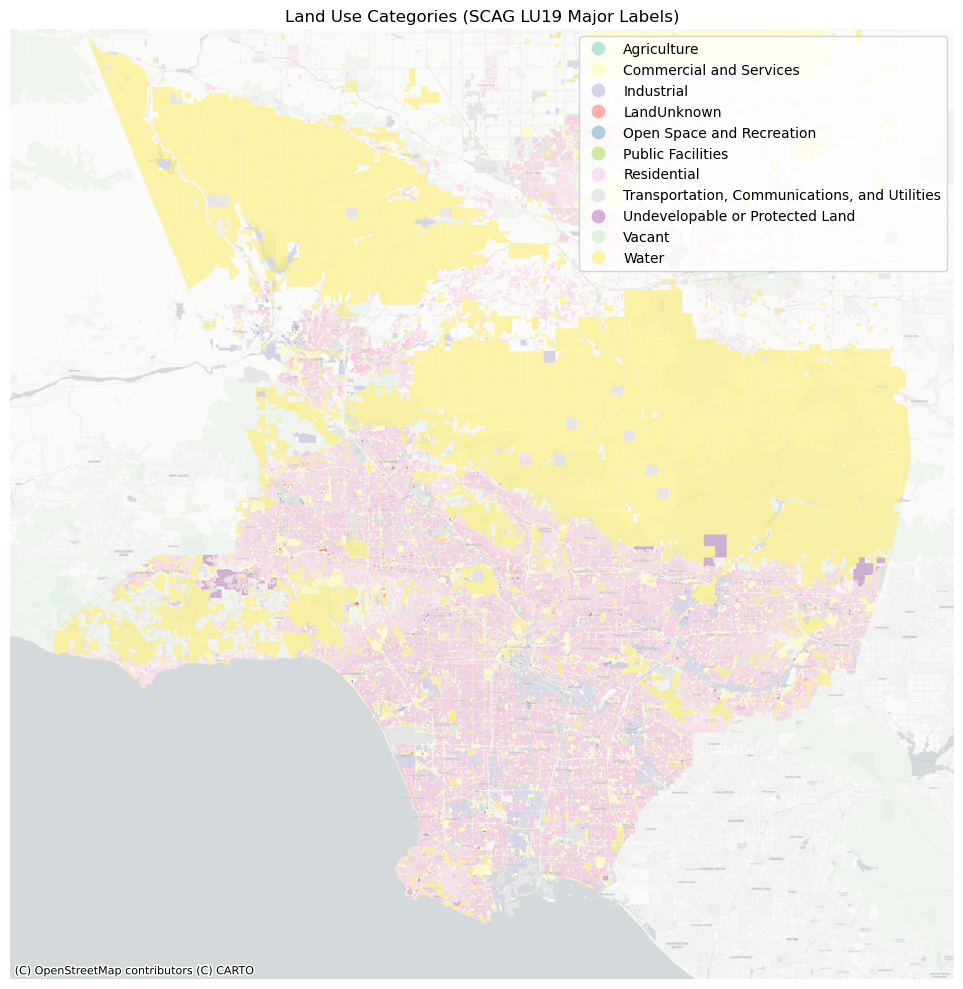

In [10]:
import matplotlib.pyplot as plt
import contextily as ctx

luGdf_map = luGdf.to_crs(epsg=3857)
fig, ax = plt.subplots(figsize=(12, 10))

luGdf_map.plot(
    column="LU19_major_label",
    cmap="Set3",
    legend=True,
    ax=ax,
    alpha=0.9)

# drop Catalina
ax.set_ylim([3.98e6, 4.14e6])
ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron, zoom=12)

# and we really don't need the axis ticks and labels, so we set them to an empty list
ax.set_xticks([])
ax.set_yticks([])

plt.title("Land Use Categories (SCAG LU19 Major Labels)")
plt.axis("off")
plt.tight_layout()
plt.show()

#### Calculating the proportion of landuse type for each tract

In [10]:
# making column of GEOID by using the first 11 digit out of 15 digit(block level)
luGdf['GEOID'] = luGdf['GEOID20'].str[:11]

In [11]:
# converting the gdf into meter based projection
luGdf_proj = luGdf.to_crs(epsg=3497)

# making a column that shows the area of each parcel
luGdf_proj['area_m2'] = luGdf_proj.geometry.area

In [12]:
# calculating the area of each landuse type for each tract
# tract_lu has rows that shows the area of each landuse type for each tract (one tract has a couple of rows for each landuse type)
tract_lu = luGdf_proj.groupby(['GEOID', 'LU19_major_label'])['area_m2'].sum().reset_index()

In [13]:
# calculating the total area for each tract and name it tract_total
tract_total = tract_lu.groupby('GEOID')['area_m2'].sum().reset_index(name='total_area_m2')

In [14]:
# calculating the proportion of each land use type for each census tract
tract_lu = tract_lu.merge(tract_total, on='GEOID')
tract_lu['percent'] = tract_lu['area_m2'] / tract_lu['total_area_m2'] * 100

#### Calculating the proportion of residential use area for each tract

In [15]:
# extracting the rows with "Residential"
tract_residential = tract_lu[tract_lu['LU19_major_label'] == 'Residential'][['GEOID', 'percent']]
tract_residential = tract_residential.rename(columns={'percent': 'pct_residential'})

##### Mapping (by using tract23)

In [16]:
tract_residential = tract_residential.set_index("GEOID")

tract_residential = tracts23.join(tract_residential, how="left")

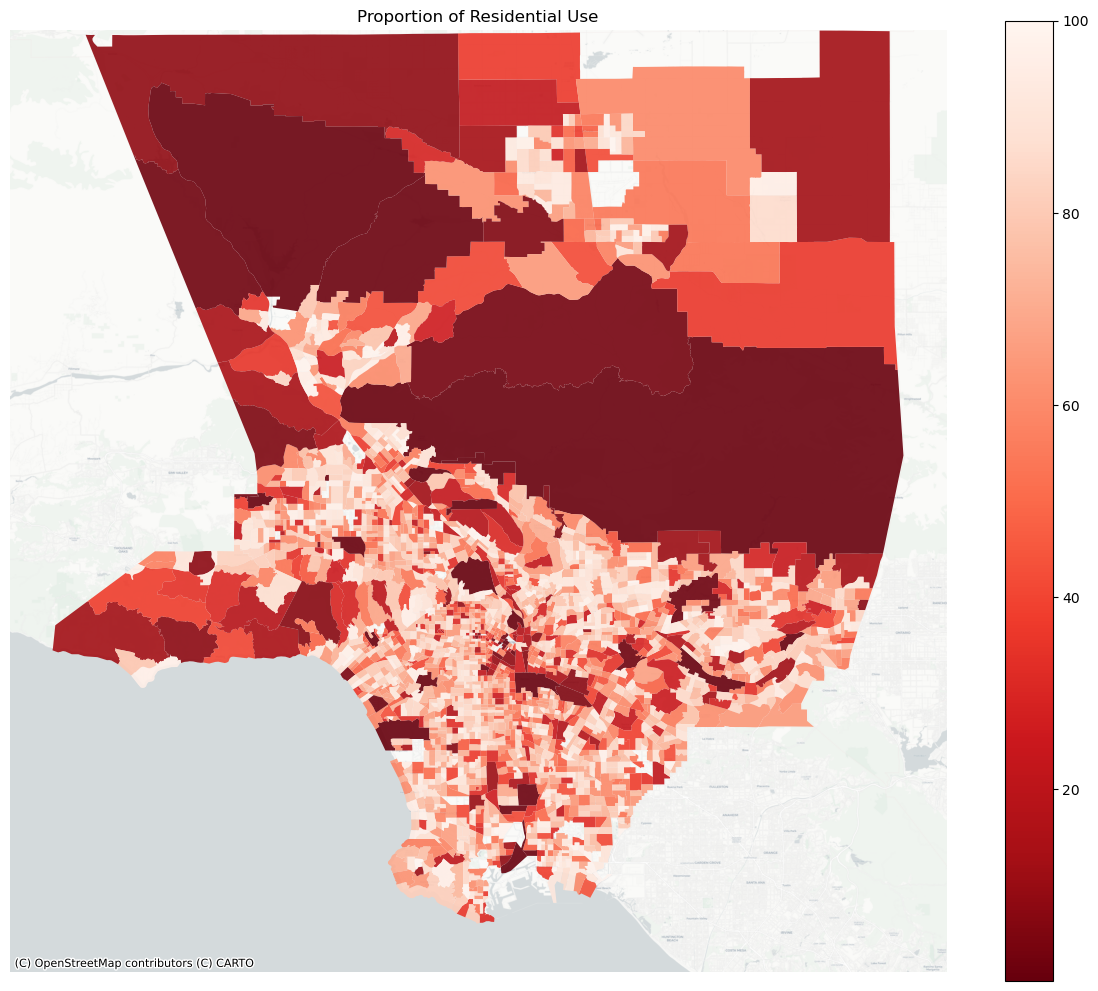

In [75]:
import contextily as ctx
import matplotlib.pyplot as plt

tract_residential_map = tract_residential.to_crs(epsg=3857)
fig, ax = plt.subplots(figsize=(12, 10))

tract_residential_map.plot(
    column='pct_residential',
    cmap='Reds_r', 
    legend=True,
    ax=ax,
    alpha=0.9)

# drop Catalina
ax.set_ylim([3.98e6, 4.14e6])
ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron, zoom=12)

# and we really don't need the axis ticks and labels, so we set them to an empty list
ax.set_xticks([])
ax.set_yticks([])

plt.title("Proportion of Residential Use")
plt.axis("off")
plt.tight_layout()
plt.show()

### making buffer polygons for each tract (2000m)

In [17]:
tracts23_buffer = tracts23.to_crs(epsg=3497)
tracts23_buffer["geometry"] = tracts23_buffer.buffer(2000)

### Amenities data

##### importing data of public facilities

Data source: https://geohub.lacity.org/maps/c5a91c789041455485de39a45d0aae0c/about

In [18]:
ArtsRecreation = gpd.read_file("data/public_facilities/ArtsRecreation.gpkg").to_crs(epsg=3497)
Education = gpd.read_file("data/public_facilities/Education.gpkg").to_crs(epsg=3497)
Hospitals = gpd.read_file("data/public_facilities/Hospitals.gpkg").to_crs(epsg=3497)
MunicipalServices = gpd.read_file("data/public_facilities/MunicipalServices.gpkg").to_crs(epsg=3497)
PhysicalFeatures = gpd.read_file("data/public_facilities/PhysicalFeatures.gpkg").to_crs(epsg=3497)
PublicSafety = gpd.read_file("data/public_facilities/PublicSafety.gpkg").to_crs(epsg=3497)
Transportation = gpd.read_file("data/public_facilities/Transportation.gpkg").to_crs(epsg=3497)

/opt/anaconda3/envs/uds/lib/python3.12/site-packages/pyogrio/raw.py:198: RuntimeWarning: This version of GeoPackage user_version=0x000028A0 (10400, v1.4.0) on 'data/public_facilities/ArtsRecreation.gpkg' may only be partially supported
  return ogr_read(
/opt/anaconda3/envs/uds/lib/python3.12/site-packages/pyogrio/raw.py:198: RuntimeWarning: This version of GeoPackage user_version=0x000028A0 (10400, v1.4.0) on 'data/public_facilities/Education.gpkg' may only be partially supported
  return ogr_read(
/opt/anaconda3/envs/uds/lib/python3.12/site-packages/pyogrio/raw.py:198: RuntimeWarning: Non-conformant content for record 1 in column last_update, 2025-03-10T00:00:00.0Z, successfully parsed
  return ogr_read(
/opt/anaconda3/envs/uds/lib/python3.12/site-packages/pyogrio/raw.py:198: RuntimeWarning: This version of GeoPackage user_version=0x000028A0 (10400, v1.4.0) on 'data/public_facilities/Hospitals.gpkg' may only be partially supported
  return ogr_read(
/opt/anaconda3/envs/uds/lib/python

##### Dropping irrelevant rows (such as jails in PublicSafety)

In [19]:
PublicSafety = PublicSafety[~PublicSafety["cat2"].isin([
    "Jails and Prisons",
    "Probation Camps and Juvenile Halls"
])].reset_index(drop=True)

##### importing data of food pantries

In [20]:
pantryDf = pd.read_csv('data/Food_Resources_in_California.csv')

#extracting data of LA county
pantryDf = pantryDf[pantryDf.County=='Los Angeles']

#changing the dataframe into geodataframe
Pantry = gpd.GeoDataFrame(
    pantryDf, geometry=gpd.points_from_xy(pantryDf.Longitude, pantryDf.Latitude, 
                                          crs='EPSG:4326'))
Pantry = Pantry.to_crs(epsg=3497)

##### importing data of public parkings (SCAG 2019)

In [21]:
Parking = luGdf[luGdf['LU19'] == 1247]
Parking = Parking.to_crs(epsg=3497)

In [22]:
Parking = Parking.set_index('GEOID')

##### Joining public facilities & pantry data with tract polygons (buffered)

In [23]:
#Codes for individual procedure
# spatial join
#tmpgdf_ms = gpd.sjoin(tracts23_buffer, MunicipalServices, predicate='intersects')

# group by
#MunicipalServices_counts = tmpgdf_ms.groupby('GEOID').size()
#MunicipalServices_counts.name = 'n_MunicipalServices'

# join back
#tracts23_buffer = tracts23_buffer.join(MunicipalServices_counts)
#tracts23_buffer.fillna({'n_MunicipalServices':0}, inplace=True)
#tracts23_buffer.n_MunicipalServices.describe()

In [24]:
#Codes using function
def count_facilities_within_tracts(tracts_gdf, points_gdf, buffer_gdf_name):
    tmp = gpd.sjoin(tracts_gdf, points_gdf, predicate='intersects')

    # counting facilities for each polygon
    counts = tmp.groupby('GEOID').size()
    counts.name = f'n_{buffer_gdf_name}'

    # join with original polygon
    tracts_gdf = tracts_gdf.join(counts)

    # filling NaN with 0
    tracts_gdf.fillna({f'n_{buffer_gdf_name}': 0}, inplace=True)

    return tracts_gdf

In [25]:
tracts23_buffer = count_facilities_within_tracts(tracts23_buffer, ArtsRecreation, 'ArtsRecreation')
tracts23_buffer = count_facilities_within_tracts(tracts23_buffer, Education, 'Education')
tracts23_buffer = count_facilities_within_tracts(tracts23_buffer, Hospitals, 'Hospitals')
tracts23_buffer = count_facilities_within_tracts(tracts23_buffer, MunicipalServices, 'MunicipalServices')
tracts23_buffer = count_facilities_within_tracts(tracts23_buffer, PhysicalFeatures, 'PhysicalFeatures')
tracts23_buffer = count_facilities_within_tracts(tracts23_buffer, PublicSafety, 'PublicSafety')
tracts23_buffer = count_facilities_within_tracts(tracts23_buffer, Transportation, 'Transportation')
tracts23_buffer = count_facilities_within_tracts(tracts23_buffer, Pantry, 'Pantry')

In [26]:
tracts23_buffer = tracts23_buffer.reset_index()

In [27]:
tmpgdf_ms = gpd.sjoin(tracts23_buffer, Parking, predicate='intersects')

Parking_counts = tmpgdf_ms.groupby('GEOID_left').size()
Parking_counts.name = 'n_Parking'

tracts23_buffer = tracts23_buffer.set_index('GEOID').join(Parking_counts).reset_index()
tracts23_buffer['n_Parking'] = tracts23_buffer['n_Parking'].fillna(0).astype(int)

##### moving all data in tracts23_buffer into tracts23

In [28]:
tracts23_geom = tracts23.reset_index().to_crs(epsg=3497)[['GEOID', 'geometry']]
tracts23 = tracts23_buffer.drop(columns='geometry').merge(tracts23_geom, on='GEOID')

In [29]:
tracts23 = tracts23.set_index('GEOID')
tracts23 = gpd.GeoDataFrame(tracts23, geometry='geometry', crs='EPSG:3497')

##### mapping number of public parkings for each tract

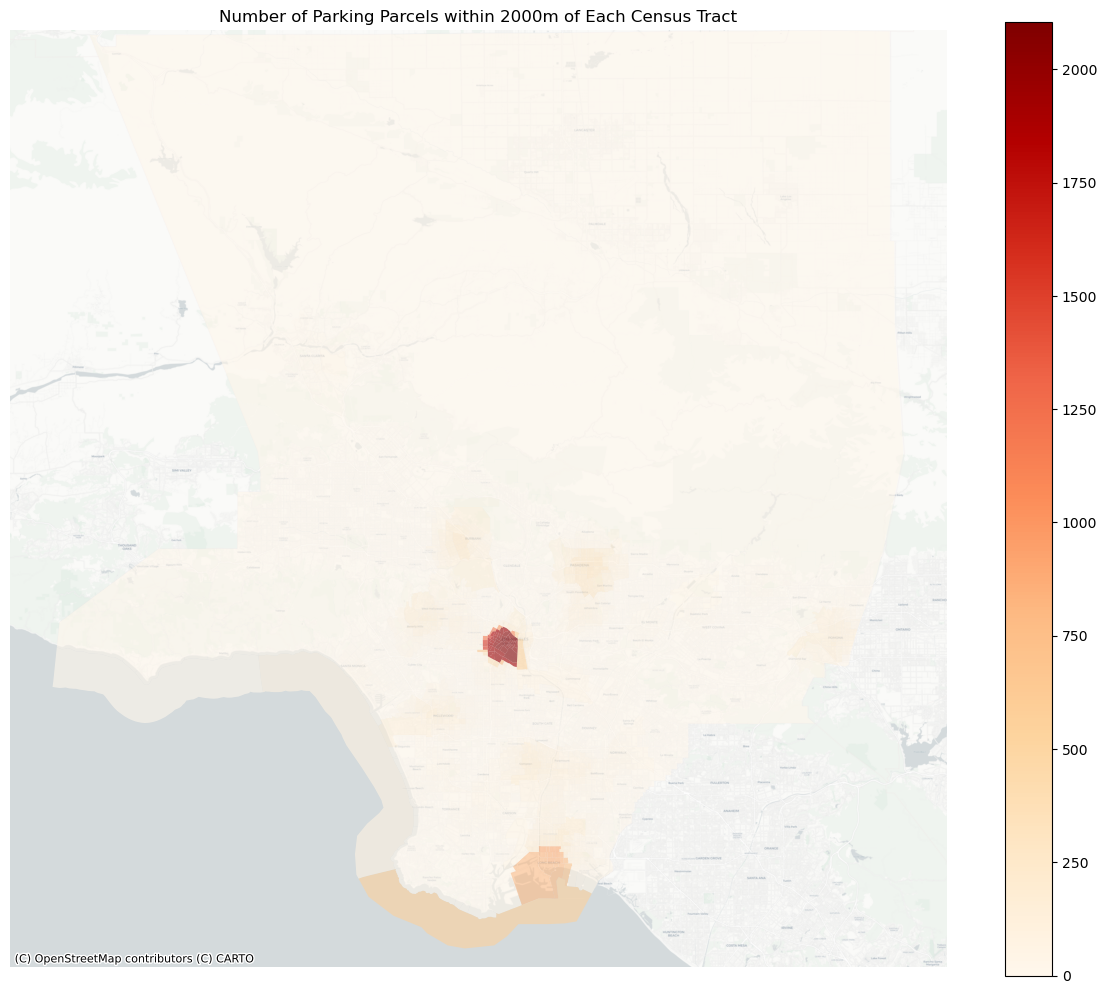

In [77]:
import contextily as ctx

tracts23_web = tracts23.to_crs(epsg=3857)
fig, ax = plt.subplots(figsize=(12, 10))

tracts23_web.plot(
    column='n_Parking',
    cmap='OrRd',
    legend=True,
    ax=ax,
    alpha=0.6)

# drop Catalina
ax.set_ylim([3.98e6, 4.14e6])

ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron, zoom=12)

ax.set_xticks([])
ax.set_yticks([])
plt.title("Number of Parking Parcels within 2000m of Each Census Tract")
plt.axis("off")
plt.tight_layout()
plt.show()

### LAHSA data

##### merging split rows (2022, 2023, 2024)

In [30]:
#defining non-merging columns
representative_cols = ['year', 'lacity', 'spa', 'sd', 'cd', 'ca_ssd', 'ca_sad', 'us_cd']

#listing years
years = [22, 23, 24]

for year in years:
    
    #loading data
    hc = pd.read_csv(f"Data/LAHSA/streetcount{year}_original.csv")

    #converting all the column names into lower case
    hc.columns = hc.columns.str.lower()

    #extracting first 6 digits of tract_split column
    hc['tract_split_base'] = hc['tract_split'].astype(str).str.extract(r'(\d{6})')

    #extracting columns that is not included in "non-merging columns"
    numeric_cols = hc.select_dtypes(include='number').columns.tolist()
    sum_cols = [col for col in numeric_cols if col not in representative_cols]

    #summing the data of mergning columns and taking the data of first row for the non-merging columns
    hc_agg = hc.groupby('tract_split_base').agg(
        {**{col: 'first' for col in representative_cols},
         **{col: 'sum' for col in sum_cols}}
    ).reset_index()

    #setting GEOID as the index
    hc_agg['GEOID'] = '06037' + hc_agg['tract_split_base']



    #saving data as CSV
    hc_agg.to_csv(f"Data/LAHSA/streetcount{year}.csv", index=False)

##### making dataframe of each year (2022-24)

In [31]:
for year in [22, 23, 24]:
    df = pd.read_csv(f"Data/LAHSA/streetcount{year}.csv", dtype={'GEOID': str})
    df = df.set_index('GEOID')   #setting GEOID as the index
    globals()[f"hc{year}"] = df  

##### LAHSA 2020 (importing separately because tracts are not split)

In [32]:
hc20 = pd.read_csv('Data/LAHSA/streetcount20.csv', dtype={'tract': str})
hc20['GEOID'] = '06037' + hc20['tract']

#setting GEOID as the index
hc20 = hc20.set_index('GEOID')

#converting all the column names into lower case
hc20.columns = hc20.columns.str.lower()

now we have LAHSA data named (hc20, hc22, hc23, hc24)

### ACS data

We have deactivated a couple of variables because the number of variables we can extract is limited to under 50 while the number of variables we listed here is 53+3(state, county, tract) = 56.
We selected the variables that overlap.

In [33]:
import requests
import pandas as pd
import numpy as np

key = 'e024759e68ac64e5f031a35c74016bdf988adce6'
years = [2020, 2022, 2023]
acs_vars = [
    "B25077_001E",  # Median home value
    "B25064_001E",  # Median gross rent
    "B25088_001E",  # Median monthly owner costs (with mortgage)

    # Renter cost burden
#    "B25070_004E",  # Rent 30.0 to 34.9% of income
#    "B25070_005E",  # Rent 35.0 to 39.9%
    "B25070_006E",  # Rent 40.0 to 49.9%
    "B25070_007E",  # Rent 50.0% or more
    "B25070_001E",  # Total renters (denominator)

    # Owner cost burden
#    "B25091_005E",  # Owner costs 30.0 to 34.9%
#    "B25091_006E",  # Owner costs 35.0 to 39.9%
    "B25091_007E",  # Owner costs 40.0 to 49.9%
    "B25091_008E",  # Owner costs 50.0% or more
    "B25091_001E",  # Total owners (denominator)

    # Labor force
    "B23025_005E",  # Unemployed
    "B23025_003E",  # Civilian labor force (denominator)

    # Poverty
    "B17001_002E",  # Population below poverty line
    "B17001_001E",  # Population for whom poverty status is determined

    "B19083_001E",  # Gini index of income inequality

    # Public assistance
    "B19057_002E",  # With public assistance income
#    "B19057_001E",  # Total households

    # HUD housing
    "B25022_002E",  # Occupied HUD-assisted units
    "B25022_001E",  # Total HUD-assisted units

    # Age of housing
    "B25034_002E",  # Units built in 1939 or earlier
#    "B25034_001E",  # Total housing units

    # Hispanic origin
    "B03003_003E",  # Hispanic or Latino population
    "B03003_001E",  # Total population

    # In-migration
    "B07001_017E",  # Movers from another U.S. county
    "B07001_001E",  # Total population 1 year and over

    # Household type
    "B11001_003E",  # One-person households
    "B11001_001E",  # Total households

    # Age: Seniors 65+ (Male)
    "B01001_020E", "B01001_021E", "B01001_022E", "B01001_023E", "B01001_024E", "B01001_025E",
    # Age: Seniors 65+ (Female)
    "B01001_044E", "B01001_045E", "B01001_046E", "B01001_047E", "B01001_048E", "B01001_049E",

    # Age: Children <18 (Male)
    "B01001_003E", "B01001_004E", "B01001_005E", "B01001_006E",
    # Age: Children <18 (Female)
    "B01001_027E", "B01001_028E", "B01001_029E", "B01001_030E",

#    "B01001_001E",  # Total population (for age shares)

    # Overcrowding
    "B25014_003E",  # 1.01 to 1.50 persons per room
    "B25014_004E",  # 1.51+ persons per room
    "B25014_001E",  # Total housing units (for overcrowding rate)

    "B25001_001E"   # Total housing units (for density)
]

acs_var_string = ",".join(acs_vars)

for year in years:
    url = f'https://api.census.gov/data/{year}/acs/acs5?get={acs_var_string}&for=tract:*&in=state:06%20county:037&key={key}'
    r = requests.get(url)

    acsdata = r.json()
    df = pd.DataFrame(acsdata[1:], columns=acsdata[0])
    df['GEOID'] = '06037' + df['tract']
    df = df.set_index('GEOID')
    df[acs_vars] = df[acs_vars].astype(float)
    globals()[f'acs{str(year)[-2:]}'] = df

import requests
import pandas as pd
import numpy as np

key = 'e024759e68ac64e5f031a35c74016bdf988adce6'
years = [2020, 2022, 2023]

# ACS variables to request
# For documentation on variables selection, see page 21, https://www.huduser.gov/portal/sites/default/files/pdf/market-predictors-of-homelessness.pdf
acs_vars = [
    "B25077_001E",  # Median home value
    "B25064_001E",  # Median gross rent
    "B25088_001E",  # Median monthly owner costs (with mortgage)

    # Renter cost burden
    "B25070_004E",  # Rent 30.0 to 34.9% of income
    "B25070_005E",  # Rent 35.0 to 39.9%
    "B25070_006E",  # Rent 40.0 to 49.9%
    "B25070_007E",  # Rent 50.0% or more
    "B25070_001E",  # Total renters (denominator)

    # Owner cost burden
    "B25091_005E",  # Owner costs 30.0 to 34.9%
    "B25091_006E",  # Owner costs 35.0 to 39.9%
    "B25091_007E",  # Owner costs 40.0 to 49.9%
    "B25091_008E",  # Owner costs 50.0% or more
    "B25091_001E",  # Total owners (denominator)

    # Labor force
    "B23025_005E",  # Unemployed
    "B23025_003E",  # Civilian labor force (denominator)

    # Poverty
    "B17001_002E",  # Population below poverty line
    "B17001_001E",  # Population for whom poverty status is determined

    "B19083_001E",  # Gini index of income inequality

    # Public assistance
    "B19057_002E",  # With public assistance income
    "B19057_001E",  # Total households

    # HUD housing
    "B25022_002E",  # Occupied HUD-assisted units
    "B25022_001E",  # Total HUD-assisted units

    # Age of housing
    "B25034_002E",  # Units built in 1939 or earlier
    "B25034_001E",  # Total housing units

    # Hispanic origin
    "B03003_003E",  # Hispanic or Latino population
    "B03003_001E",  # Total population

    # In-migration
    "B07001_017E",  # Movers from another U.S. county
    "B07001_001E",  # Total population 1 year and over

    # Household type
    "B11001_003E",  # One-person households
    "B11001_001E",  # Total households

    # Age: Seniors 65+ (Male)
    "B01001_020E", "B01001_021E", "B01001_022E", "B01001_023E", "B01001_024E", "B01001_025E",
    # Age: Seniors 65+ (Female)
    "B01001_044E", "B01001_045E", "B01001_046E", "B01001_047E", "B01001_048E", "B01001_049E",

    # Age: Children <18 (Male)
    "B01001_003E", "B01001_004E", "B01001_005E", "B01001_006E",
    # Age: Children <18 (Female)
    "B01001_027E", "B01001_028E", "B01001_029E", "B01001_030E",

    "B01001_001E",  # Total population (for age shares)

    # Overcrowding
    "B25014_003E",  # 1.01 to 1.50 persons per room
    "B25014_004E",  # 1.51+ persons per room
    "B25014_001E",  # Total housing units (for overcrowding rate)

    "B25001_001E"   # Total housing units (for density)
]

# Dictionary to store dataframes by year
acs_data_by_year = {}

for year in years:
    print(f"Downloading ACS {year} data...")

    var_string = ",".join(acs_vars)
    url = f'https://api.census.gov/data/{year}/acs/acs5?get={var_string}&for=tract:*&in=state:06 county:037&key={key}'

    r = requests.get(url)
    if r.status_code != 200:
        print(f"Failed to fetch data for {year}: {r.status_code}")
        continue

    data = r.json()
    df = pd.DataFrame(data[1:], columns=data[0])

    # Make GEOID
    df['GEOID'] = '06037' + df['tract']
    df.set_index('GEOID', inplace=True)
    df.drop(columns=['state', 'county', 'tract'], inplace=True)

    # Convert all columns to numeric (coerce errors to NaN)
    for col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

    # Store cleaned dataframe
    acs_data_by_year[year] = df


In [16]:
#import requests
#import json
#import numpy as np

#key = 'e024759e68ac64e5f031a35c74016bdf988adce6'
#years = [2020, 2022, 2023]
#acs_vars = [
#     "B25077_001E",  # Median home value
#     "B25064_001E",  # Median gross rent
#     "B25088_001E",  # Median selected monthly owner costs (with mortgage)
#     "B25070_004E",  # Rent 30.0 to 34.9% of household income
#     "B25070_005E",  # Rent 35.0 to 39.9%
#     "B25070_006E",  # Rent 40.0 to 49.9%
#     "B25070_007E",  # Rent 50.0% or more
#     "B25070_001E",  # Total renters (denominator)
#     "B25091_005E",  # Owner cost 30.0 to 34.9% of household income
#     "B25091_006E",  # Owner cost 35.0 to 39.9%
#     "B25091_007E",  # Owner cost 40.0 to 49.9%
#     "B25091_008E",  # Owner cost 50.0% or more
#     "B25091_001E",  # Total owners (denominator)
#     "B23025_005E",  # Unemployed
#     "B23025_003E",  # Civilian labor force (denominator)
#     "B17001_002E",  # Income below poverty level
#     "B17001_001E",  # Total population for poverty status
#     "B19083_001E",  # Gini index of income inequality
#     "B19057_002E",  # With public assistance income
#     "B19057_001E",  # Total households
#     "B25022_002E",  # HUD-subsidized units occupied
#     "B25022_001E",  # Total HUD-subsidized units
#     "B25034_002E",  # Housing units built in 1939 or earlier
#     "B25034_001E",  # Total housing units (for % pre-1940)
#     "B03003_003E",  # Hispanic or Latino population
#     "B03003_001E",  # Total population (for % Hispanic)
#     "B07001_017E",  # Movers from different U.S. county
#     "B07001_001E",  # Population 1 year and over
#     "B11001_003E",  # One-person households
#     "B11001_001E",  # Total households
#     "B01001_020E", "B01001_021E", "B01001_022E", "B01001_023E", "B01001_024E", "B01001_025E",  # Male 65+
#     "B01001_044E", "B01001_045E", "B01001_046E", "B01001_047E", "B01001_048E", "B01001_049E",  # Female 65+
#     "B01001_003E", "B01001_004E", "B01001_005E", "B01001_006E",  # Male under 18
#     "B01001_027E", "B01001_028E", "B01001_029E", "B01001_030E",  # Female under 18
#     "B01001_001E",  # Total population (for age shares)
#     "B25014_003E",  # Occupants per room: 1.01 to 1.50
#     "B25014_004E",  # Occupants per room: 1.51 or more
#     "B25014_001E",  # Total housing units (for overcrowding)
#     "B25001_001E"   # Total housing units (for density)
# ]

#acs_var_string = ",".join(acs_vars)

#for year in years:
#     url = f'https://api.census.gov/data/{year}/acs/acs5?get={acs_vars}&for=tract:*&in=state:06%20county:037&key={key}'
#     r = requests.get(url)
#     acsdata = r.json()
#     df = pd.DataFrame(acsdata[1:], columns=acsdata[0])

     #making GEOID column
#     df['GEOID'] = '06037' + df['tract']

     #setting GEOID as the index
#     df = df.set_index('GEOID')

     #changing the data type of columns into int
#     cols_to_convert = ['B25003_001E', 'B25003_002E', 'B25003_003E', 'B19013_001E']
#     df[acs_vars] = df[acs_vars].astype(float)

     #making usable variables by calculation
#     df['pct_renter'] = df['B25003_003E'] / df['B25003_001E'] * 100

#     #renaming the columns
#     df.rename(columns={'B19013_001E': 'median_hh_income'}, inplace=True)
    
#     # replacing -666666666 in "median_hh_income" into NaN
#     df["median_hh_income"] = df["median_hh_income"].replace(-666666666, np.nan)
    
     #making dataframes named acs20, acs22, acs23
#     globals()[f'acs{str(year)[-2:]}'] = df

now we have ACS data named (acs20, acs22, acs23)

#### data cleaning

In [72]:
import numpy as np

acs20 = acs20.applymap(lambda x: np.nan if isinstance(x, (int, float)) and x < 0 else x)
acs22 = acs22.applymap(lambda x: np.nan if isinstance(x, (int, float)) and x < 0 else x)
acs23 = acs23.applymap(lambda x: np.nan if isinstance(x, (int, float)) and x < 0 else x)

/var/folders/lx/_3z8wwyx3ds15_0k28hby_h80000gn/T/ipykernel_3025/2317457581.py:3: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  acs20 = acs20.applymap(lambda x: np.nan if isinstance(x, (int, float)) and x < 0 else x)
/var/folders/lx/_3z8wwyx3ds15_0k28hby_h80000gn/T/ipykernel_3025/2317457581.py:4: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  acs22 = acs22.applymap(lambda x: np.nan if isinstance(x, (int, float)) and x < 0 else x)
/var/folders/lx/_3z8wwyx3ds15_0k28hby_h80000gn/T/ipykernel_3025/2317457581.py:5: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  acs23 = acs23.applymap(lambda x: np.nan if isinstance(x, (int, float)) and x < 0 else x)


### checking the match rate

##### Tiger/Line and ACS

In [35]:
#getting index as set
index_tracts = set(tracts20.index)
index_acs = set(acs20.index)

#counting the shared GEOIDs
common_geoids = index_tracts & index_acs
num_common = len(common_geoids)

#counting the GEOID of each dataframe
num_tracts = len(index_tracts)
num_acs = len(index_acs)

#calculating the matching ratio
match_rate_tracts = num_common / num_tracts
match_rate_acs = num_common / num_acs
print(match_rate_tracts)
print(match_rate_acs)

1.0
1.0


100% matching rate between ACS and Tiger/Lines after 2020

##### Tiger/Line and LAHSA

In [36]:
#getting index as set
index_tracts = set(tracts20.index)
index_hc = set(hc23.index)

#counting the shared GEOIDs
common_geoids = index_tracts & index_hc
num_common = len(common_geoids)

#counting the GEOID of each dataframe
num_tracts = len(index_tracts)
num_hc = len(index_hc)

#calculating the matching ratio
match_rate_tracts = num_common / num_tracts
match_rate_hc = num_common / num_hc
print(match_rate_tracts)
print(match_rate_hc)

0.9251401120896717
1.0


- LAHSA has applied the 2020 census tract code after 2023 and use 2010 census tract code in 2020 and 2022. (85% out LAHSA tracts matched and 75% of census tracts matched)
- Even 2023, matching rate is 93% (LAHSA data does not include all census tracts)

##### ACS and LAHSA

In [37]:
#getting index as set
index_hc = set(hc22.index)
index_acs = set(acs20.index)

#counting the shared GEOIDs
common_index = index_hc & index_acs
num_common = len(common_index)

#counting the GEOID of each dataframe
num_hc = len(index_hc)
num_acs = len(index_acs)

#calculating the matching ratio
match_rate_hc = num_common / num_hc
match_rate_acs = num_common / num_acs
print(match_rate_hc)
print(match_rate_acs)

0.8571428571428571
0.7421937550040032


same with the result of the section above

### joining data

##### ACS and LAHSA of each year

In [73]:
merged20 = acs20.join(hc20, how='left', rsuffix='_hc')
merged22 = acs22.join(hc22, how='left', rsuffix='_hc')
merged23 = acs23.join(hc23, how='left', rsuffix='_hc')

##### adding the column indicating the year of the data

In [74]:
merged20["year"] = 2020
merged22["year"] = 2022
merged23["year"] = 2023

##### resetting the index (changing GEOID into normal column)

In [75]:
merged20 = merged20.reset_index()
merged22 = merged22.reset_index()
merged23 = merged23.reset_index()

##### merging data of different years

In [143]:
merged_all = pd.concat([merged20, merged22, merged23], axis=0).reset_index(drop=True)

##### merging amenity data by using GEOID column

In [144]:
tracts23 = tracts23.reset_index()

cols_to_merge = ['GEOID',
                 'n_ArtsRecreation',
                 'n_Education',
                 'n_Hospitals',
                 'n_MunicipalServices',
                 'n_PhysicalFeatures',
                 'n_PublicSafety',
                 'n_Transportation',
                 'n_Pantry',
                 'n_Parking']
tract_counts = tracts23[cols_to_merge].copy()
merged_all = merged_all.merge(tract_counts, on="GEOID", how="left")

##### merging geometry (TIGER/Line 2023) column by using GEOID 

In [78]:
tracts23 = tracts23.reset_index()

ValueError: cannot insert level_0, already exists

In [145]:
geometry23 = tracts23[["GEOID", "geometry"]]
merged_all = merged_all.merge(geometry23, on="GEOID", how="left")
merged_all = gpd.GeoDataFrame(merged_all, geometry="geometry", crs=4326)

#### creating variables made by aggregating a couple of variables

In [146]:
merged_all['total_vehicle']=merged_all['totcars']+merged_all['totvans']+merged_all['totcampers']
merged_all['total_unsheltered']=merged_all['totcars']+merged_all['totvans']+merged_all['totcampers']+merged_all['tottents']+merged_all['totencamp']
merged_all['non_vehicle_unsheltered']=merged_all['tottents']+merged_all['totencamp']

#### creating location variables of each tract by taking the centroid 

In [147]:
centroids = merged_all.geometry.centroid

merged_all["lon"] = centroids.x
merged_all["lat"] = centroids.y

/var/folders/lx/_3z8wwyx3ds15_0k28hby_h80000gn/T/ipykernel_3025/2750656393.py:1: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  centroids = merged_all.geometry.centroid


#### exporting the geodataframe as gpkg file

In [148]:
merged_all.to_file("Data/merged_all.gpkg", layer="merged_all", driver="GPKG")

In [149]:
merged_all.to_csv("Data/merged_all.csv", index=False)

#### checking the data quality

In [150]:
merged_all["B17001_002E"].describe()

count    7494.000000
mean      542.848946
std       396.826300
min         0.000000
25%       245.000000
50%       450.500000
75%       752.000000
max      3270.000000
Name: B17001_002E, dtype: float64

### Machine Learning

In [151]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

# your code here
# I'm just going to throw in all of the columns
xvars = ['year',
         'n_ArtsRecreation',
         'n_Education',
         'n_Hospitals',
         'n_MunicipalServices',
         'n_PhysicalFeatures',
         'n_PublicSafety',
         'n_Transportation',
         'n_Pantry',
         'n_Parking',
         'non_vehicle_unsheltered',
         'lon',
         'lat']

acs_vars = [
    "B25077_001E", "B25064_001E", "B25088_001E",
    "B25070_006E", "B25070_007E", "B25070_001E",
    "B25091_007E", "B25091_008E", "B25091_001E",
    "B23025_005E", "B23025_003E",
    "B17001_002E", "B17001_001E",
    "B19083_001E",
    "B19057_002E",
    "B25022_002E", "B25022_001E",
    "B25034_002E",
    "B03003_003E", "B03003_001E",
    "B07001_017E", "B07001_001E",
    "B11001_003E", "B11001_001E",
    "B01001_020E", "B01001_021E", "B01001_022E", "B01001_023E", "B01001_024E", "B01001_025E",
    "B01001_044E", "B01001_045E", "B01001_046E", "B01001_047E", "B01001_048E", "B01001_049E",
    "B01001_003E", "B01001_004E", "B01001_005E", "B01001_006E",
    "B01001_027E", "B01001_028E", "B01001_029E", "B01001_030E",
    "B25014_003E", "B25014_004E", "B25014_001E",
    "B25001_001E"
]

# Combine both lists
xvars = xvars + acs_vars

yvar = 'total_vehicle'

# create a dataframe with no NaNs
df_to_fit = merged_all[xvars+[yvar]].dropna()

In [152]:
# train test split
X_train, X_test, y_train, y_test = train_test_split(
    df_to_fit[xvars], df_to_fit[yvar], test_size = 0.25, random_state = 1)
print(len(X_train), len(y_train) )
print(len(X_test), len(y_test) )

2796 2796
933 933


In [153]:
# initialize the random forest classifer object
rf = RandomForestRegressor(n_estimators = 50, random_state = 1)

# now fit the model
rf.fit(X_train, y_train)

# make predictions
y_pred = rf.predict(X_test)
y_pred

array([6.800e+00, 1.134e+01, 5.760e+00, 5.920e+00, 3.860e+00, 6.100e+00,
       4.980e+00, 4.140e+00, 7.200e+00, 2.200e+00, 5.940e+00, 3.980e+00,
       3.060e+00, 6.420e+00, 2.580e+00, 7.920e+00, 3.420e+00, 2.200e+00,
       1.820e+00, 4.980e+00, 6.200e-01, 1.560e+00, 1.500e+00, 1.340e+00,
       3.546e+01, 1.060e+00, 1.056e+01, 7.466e+01, 9.160e+00, 1.660e+00,
       4.940e+00, 7.980e+00, 3.260e+00, 8.100e+00, 3.040e+00, 1.900e+00,
       1.100e+00, 7.820e+00, 1.700e+00, 2.620e+00, 3.080e+00, 1.570e+01,
       3.340e+00, 5.500e+00, 7.200e-01, 4.660e+00, 6.600e-01, 2.734e+01,
       6.220e+00, 6.040e+00, 4.920e+00, 2.040e+00, 3.660e+00, 2.940e+00,
       1.600e+00, 6.040e+00, 1.102e+01, 1.700e+00, 4.960e+00, 1.580e+00,
       5.200e-01, 1.560e+00, 7.800e-01, 3.820e+00, 5.140e+00, 3.480e+00,
       2.000e+00, 4.360e+00, 2.100e+00, 2.160e+00, 5.720e+00, 1.620e+00,
       1.460e+00, 8.340e+00, 2.080e+00, 4.340e+00, 5.040e+00, 3.640e+00,
       2.780e+00, 5.540e+00, 4.800e+00, 7.120e+00, 

In [154]:
print('Predicted fraction True: {:.4f}. Actual fraction True: {:.4f}'.format(
    y_pred.mean(), y_test.mean()))

Predicted fraction True: 6.4088. Actual fraction True: 5.6120


5.92983922829582


Text(0, 0.5, 'Predicted homelessness vehicle')

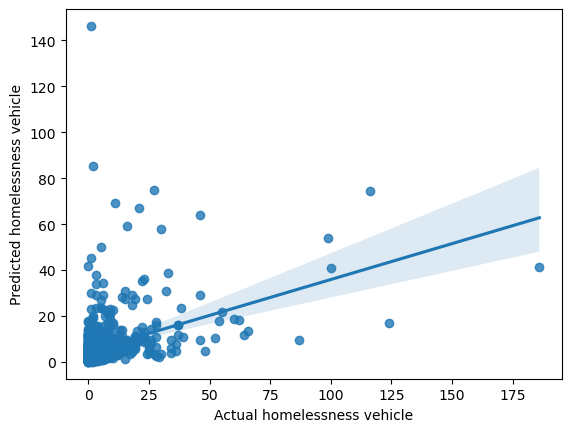

In [155]:
from sklearn import metrics
import seaborn as sns
import matplotlib.pyplot as plt

# I used mean absolute error
print(metrics.mean_absolute_error(y_test, y_pred))

# but the scatter plot is more helpful to me
fig, ax = plt.subplots()
sns.regplot(x=y_test, y=y_pred, ax=ax)
ax.set_xlabel('Actual homelessness vehicle')
ax.set_ylabel('Predicted homelessness vehicle')

### Feature importances

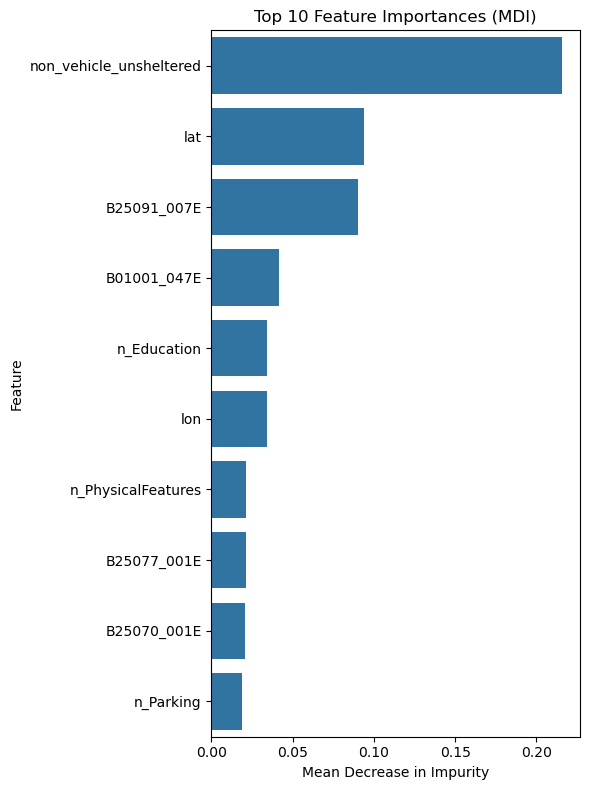

In [157]:
import numpy as np
import seaborn as sns

importances = rf.feature_importances_

# convert to a series, and give the index labels from our X_train dataframe
forest_importances = pd.Series(importances, index=X_train.columns)

# get the standard deviations to be able to plot the error bars
# acutally, these are no longer supported (for now) in seaborn, so we won't plot them
std = np.std([tree.feature_importances_ for tree in rf.estimators_], axis=0)

# sort the importances in descending order

forest_importances.sort_values(ascending=False, inplace=True)

# plot just the top 10
fig, ax = plt.subplots(figsize=(6, 8))
sns.barplot(x=forest_importances.values[:10], y=forest_importances.index[:10], ax=ax)
ax.set_title("Top 10 Feature Importances (MDI)")
ax.set_xlabel("Mean Decrease in Impurity")
ax.set_ylabel("Feature")
plt.tight_layout()
plt.show()

##### Top 10 predictors of the tract with high vehicle homelessness
B25091_007E: # Owner costs 40.0 to 49.9%  
B25077_001E: # Median home value  
B03003_003E: # Hispanic or Latino population  
B25070_001E: # Total renters (denominator)

### Partial dependence plots

In [158]:
forest_importances

non_vehicle_unsheltered    0.215962
lat                        0.093737
B25091_007E                0.090168
B01001_047E                0.041924
n_Education                0.034405
                             ...   
n_Hospitals                0.003613
B01001_028E                0.003585
B25034_002E                0.003502
B03003_001E                0.001895
year                       0.001495
Length: 61, dtype: float64

In [159]:
forest_importances.index[:10]

Index(['non_vehicle_unsheltered', 'lat', 'B25091_007E', 'B01001_047E',
       'n_Education', 'lon', 'n_PhysicalFeatures', 'B25077_001E',
       'B25070_001E', 'n_Parking'],
      dtype='object')

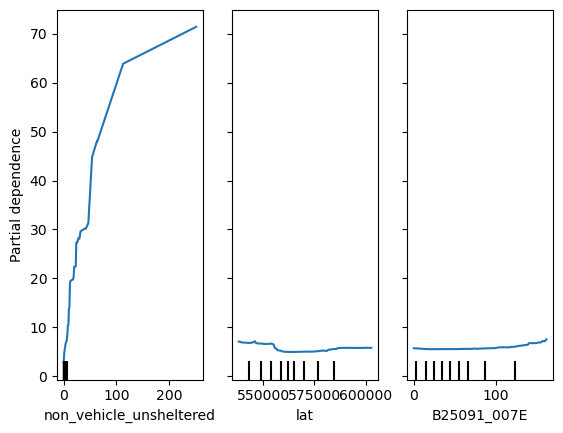

In [160]:
from sklearn.inspection import PartialDependenceDisplay

PartialDependenceDisplay.from_estimator(rf, X_test,
                                       forest_importances.index[:3])

#### Pairplots

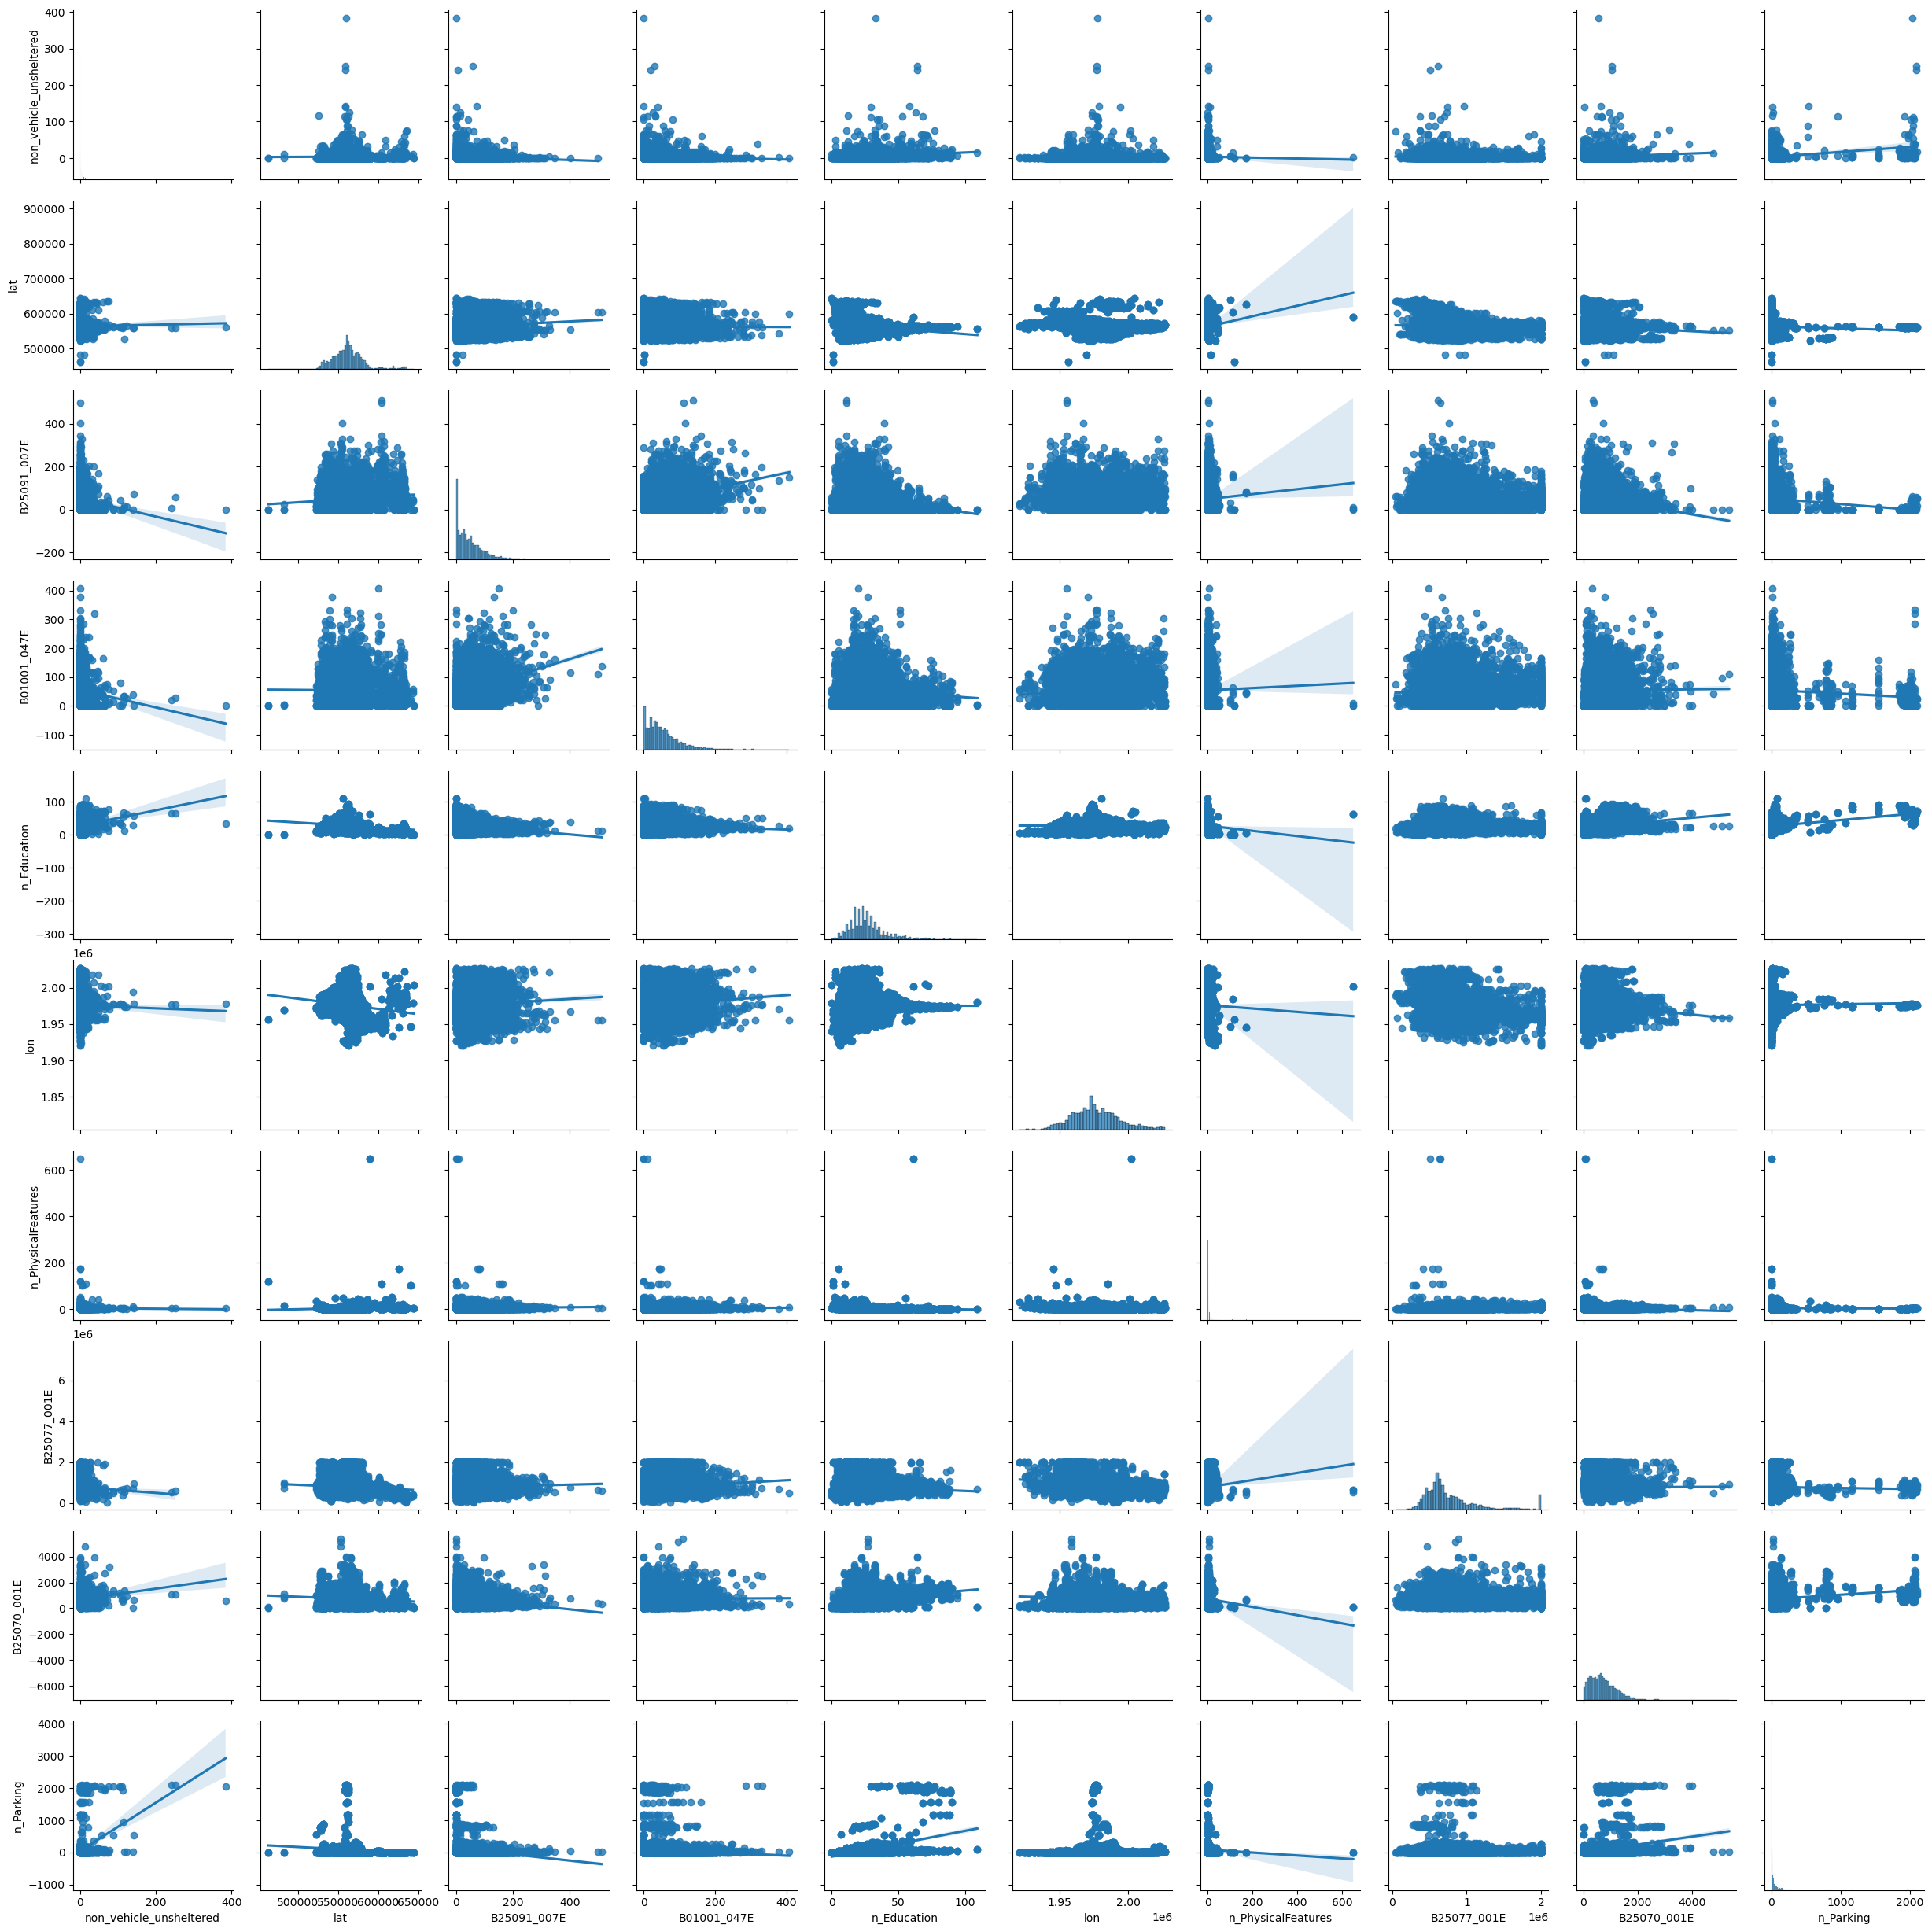

In [162]:
import seaborn as sns
cols_to_plot = forest_importances.index[:10]
ax = sns.pairplot(merged_all[cols_to_plot], kind='reg')  

#### Standardization

In [163]:
from sklearn import preprocessing
scaler = preprocessing.StandardScaler().fit(merged_all[cols_to_plot])

In [165]:
merged_all_scaled = pd.DataFrame(scaler.transform(merged_all[cols_to_plot]), 
                         columns=cols_to_plot, index=merged_all.index)

#### Pairplots with standardized data

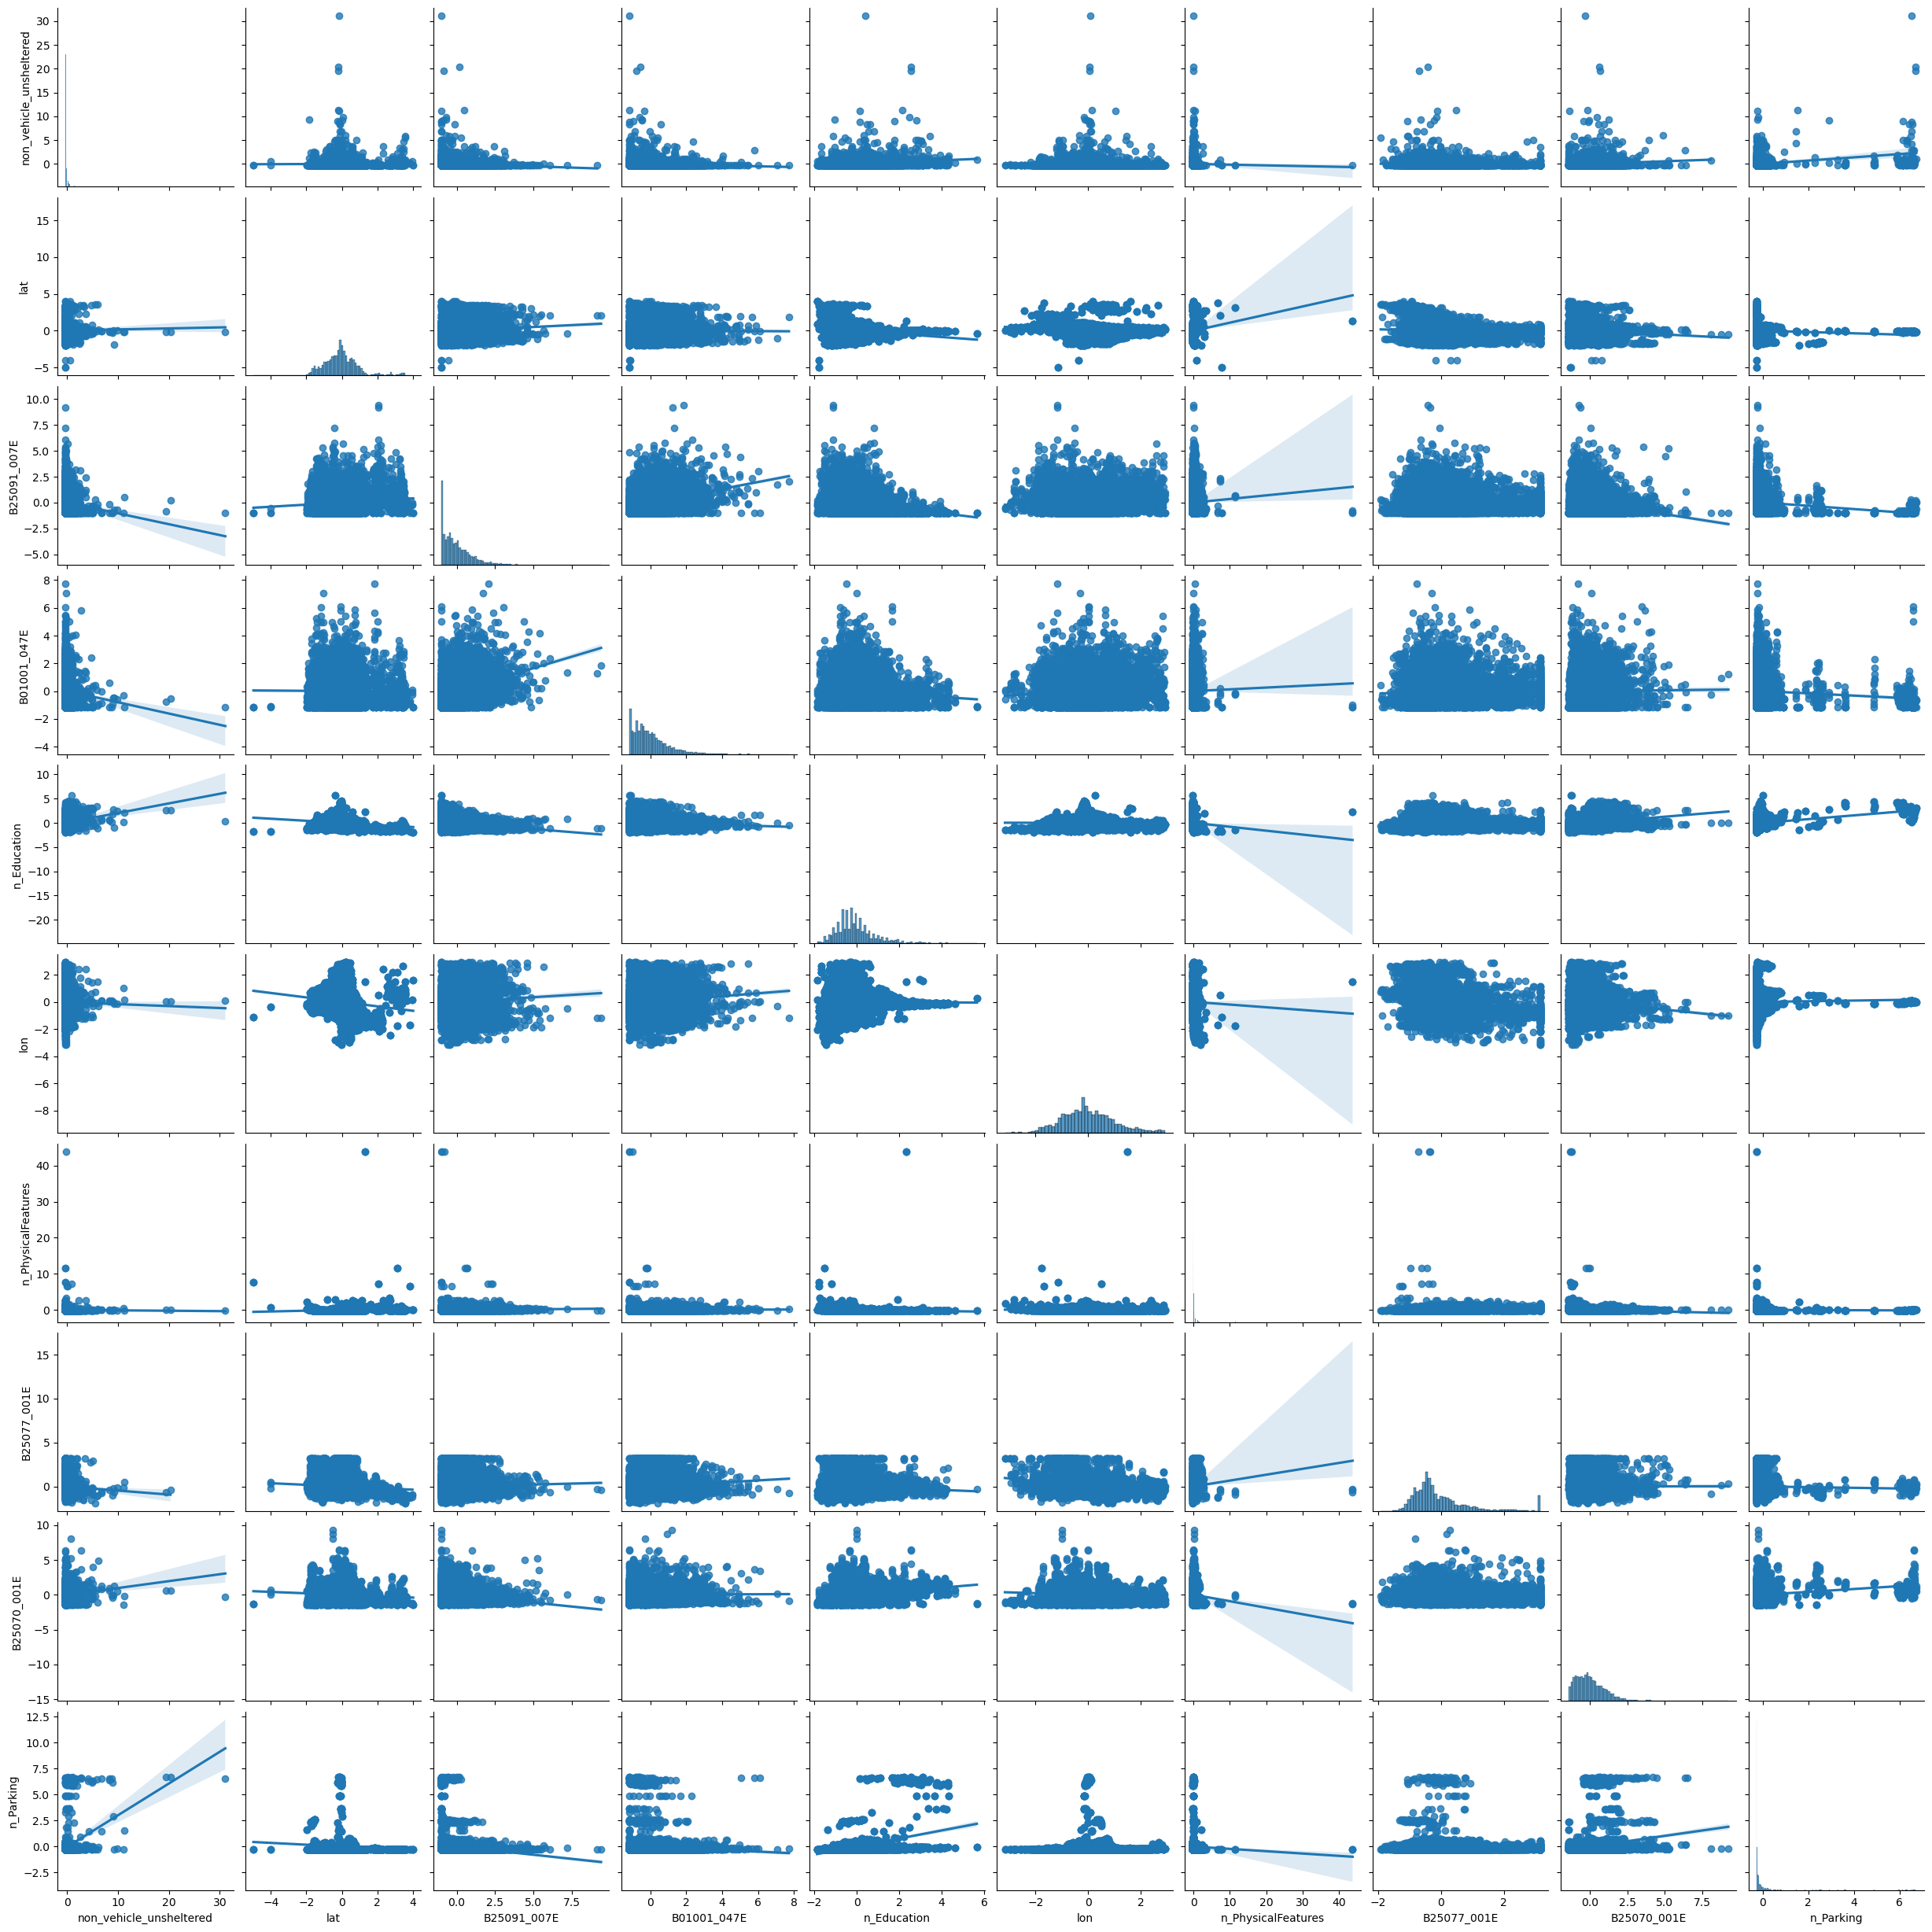

In [166]:
ax = sns.pairplot(merged_all_scaled, kind='reg')

### Cluster Analysis

In [167]:
from sklearn.cluster import KMeans
merged_all_scaled = merged_all_scaled.dropna()
kmeans = KMeans(n_clusters=5, random_state=0).fit(merged_all_scaled)

In [168]:
merged_all_scaled['cluster_id'] = kmeans.labels_

/var/folders/lx/_3z8wwyx3ds15_0k28hby_h80000gn/T/ipykernel_3025/1920520206.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_all_scaled['cluster_id'] = kmeans.labels_


In [169]:
merged_all_scaled.groupby('cluster_id').size()

cluster_id
0    1450
1    1203
2     778
3       1
4     496
dtype: int64

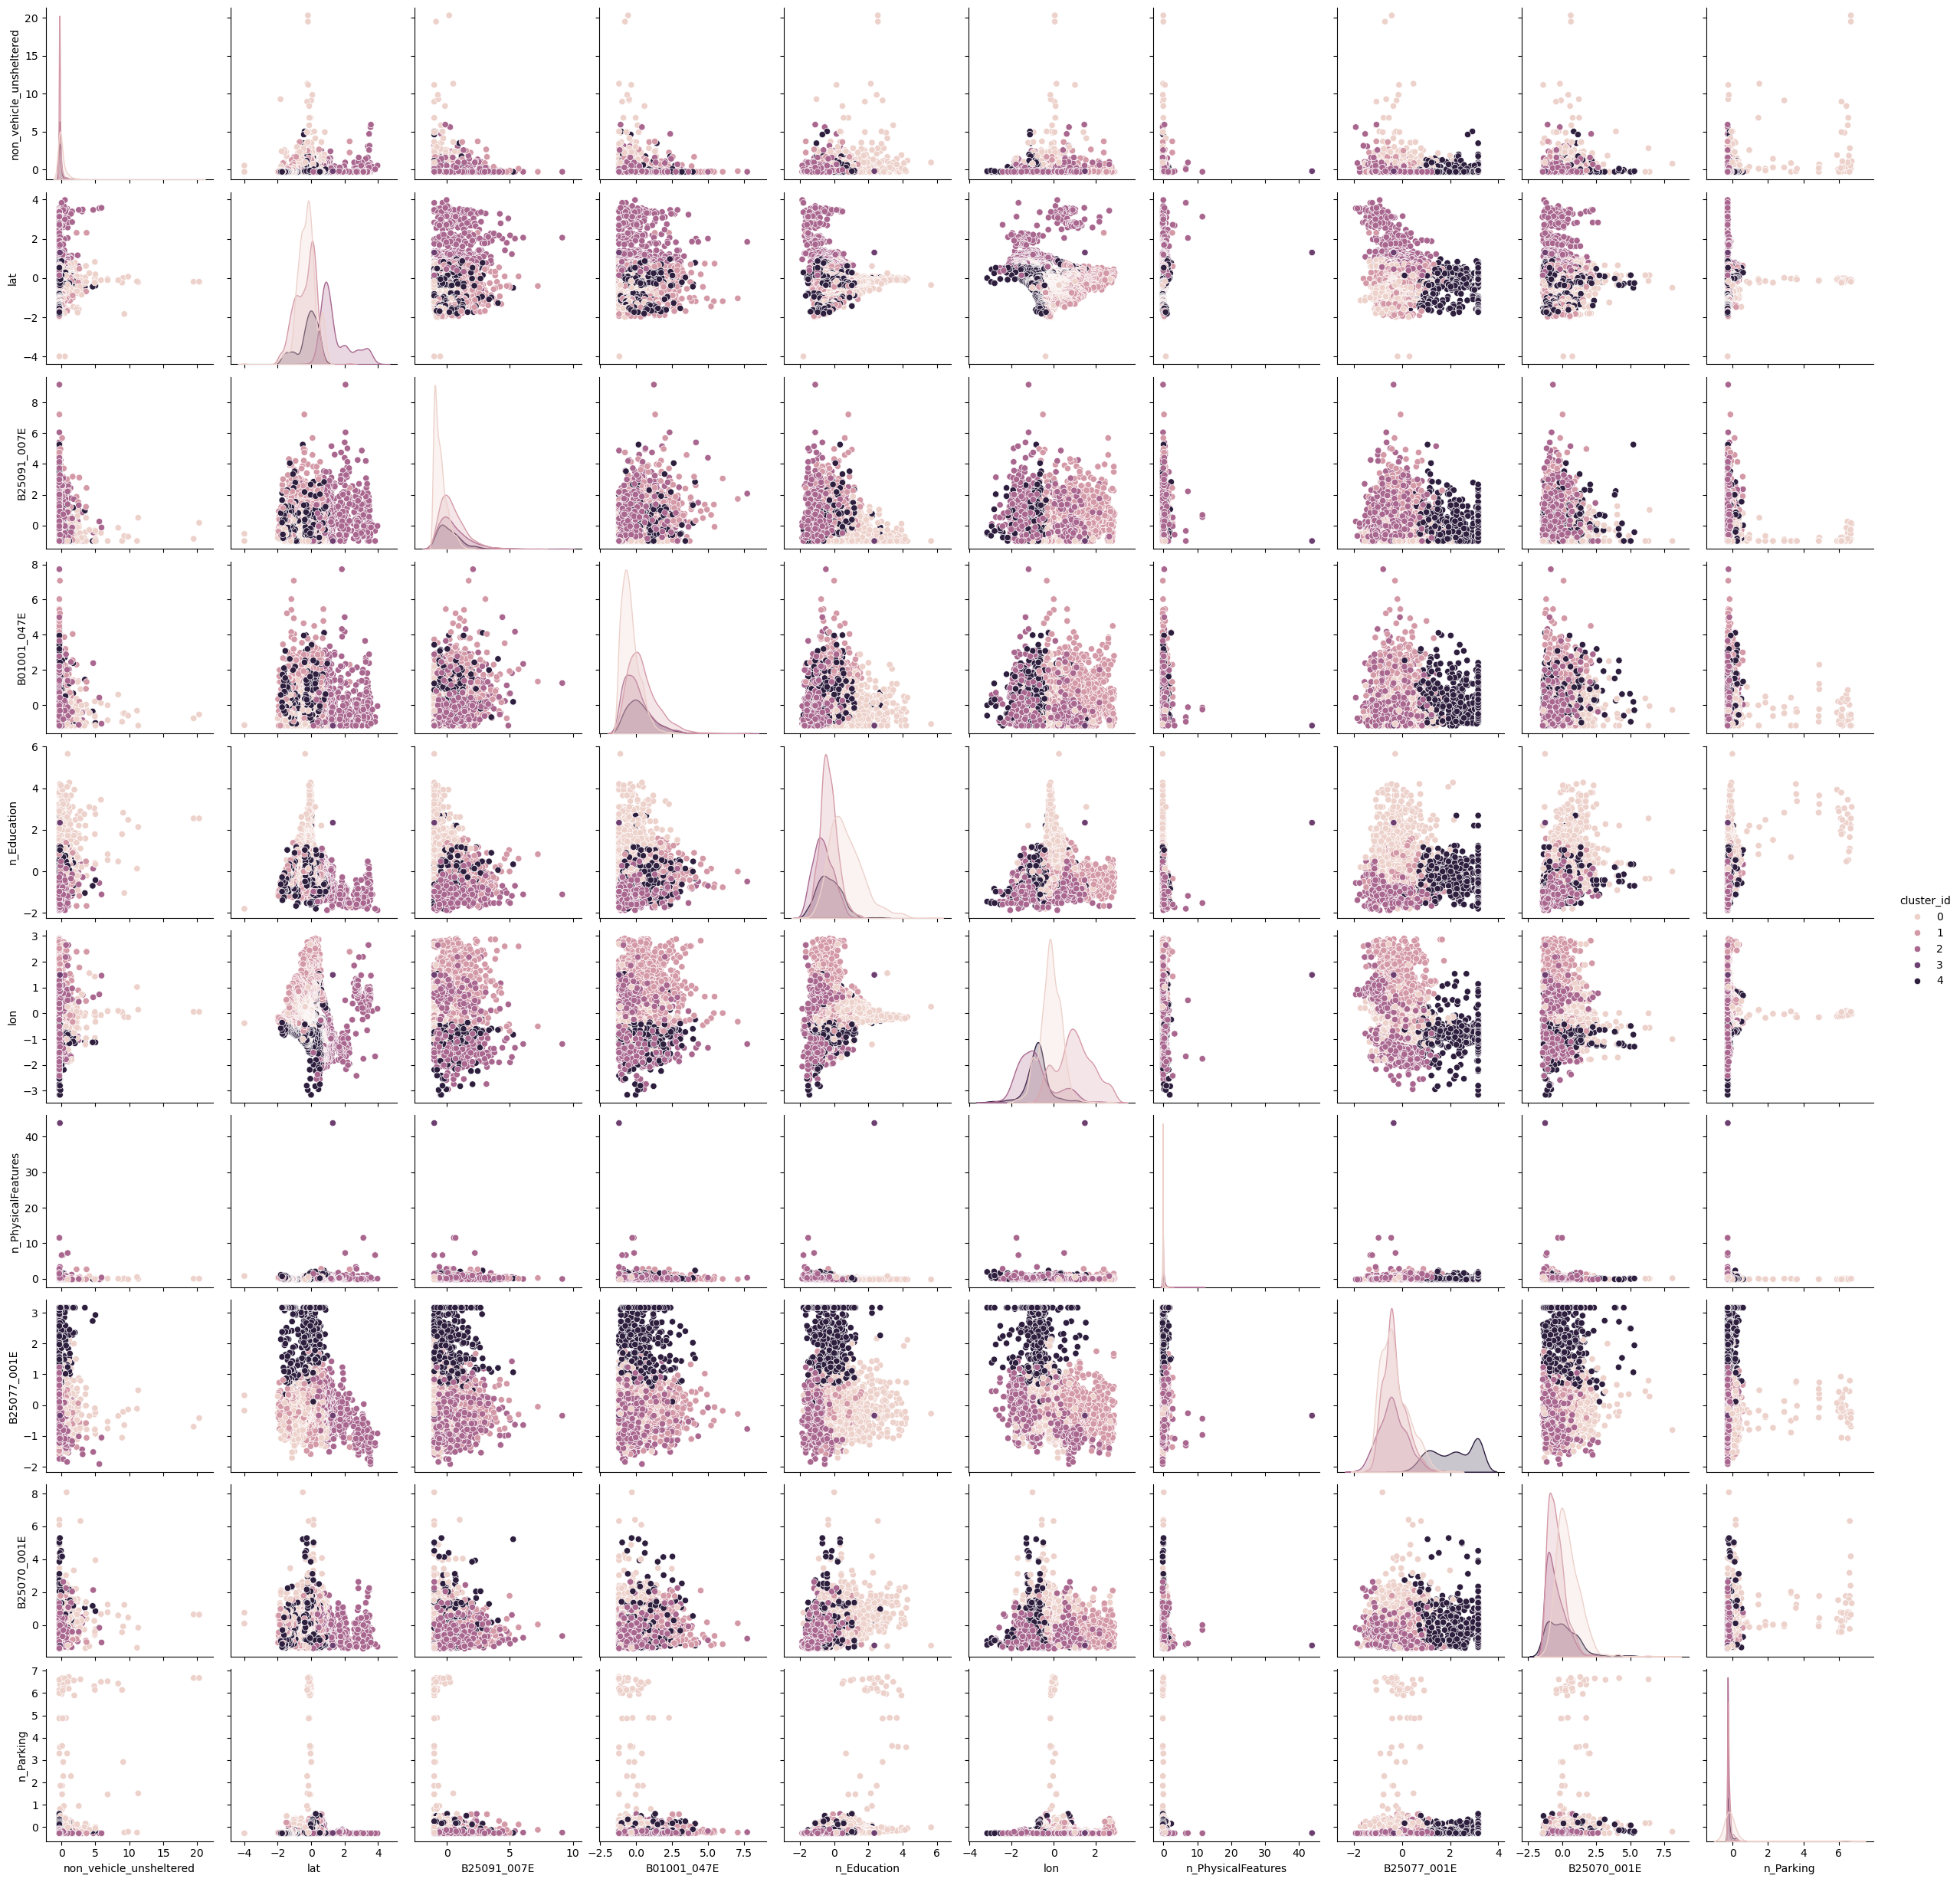

In [170]:
ax = sns.pairplot(merged_all_scaled, hue='cluster_id', )

### Mapping the clusters

In [181]:
merged_all['cluster_id'] = merged_all_scaled['cluster_id']

merged23_clustered = merged23.merge(
    merged_all[['GEOID', 'year', 'cluster_id']],
    on=['GEOID', 'year'],
    how='left'
)

In [182]:
merged23_clustered = merged23_clustered.merge(
    tracts23[['GEOID', 'geometry']], on='GEOID', how='left'
)

merged23_clustered = gpd.GeoDataFrame(
    merged23_clustered, geometry='geometry', crs=tracts23.crs
)

In [183]:
merged23_clustered.cluster_id = merged23_clustered.cluster_id.astype(str)
merged23_clustered.cluster_id = merged23_clustered.cluster_id.str.replace('.0', '')
merged23_clustered.cluster_id = merged23_clustered.cluster_id.str.replace('nan', 'No data')

[]

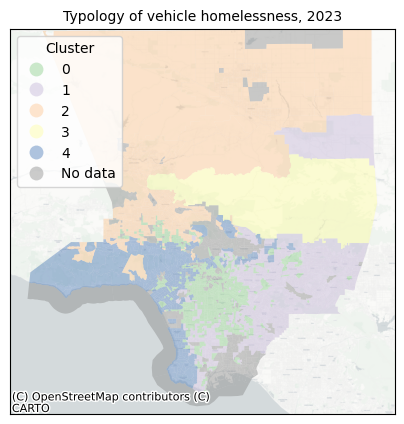

In [187]:
import contextily as ctx
from matplotlib.colors import LinearSegmentedColormap

cmap = LinearSegmentedColormap.from_list(
    'mycmap', [(0, '#7fc97f'), (0.2, '#beaed4'), (0.4, '#fdc086'), 
               (0.6, '#ffff99'), (0.8, '#386cb0'), (1.0, '0.5')])

fig, ax = plt.subplots(figsize=(5,5))
merged23_clustered.to_crs('EPSG:3857').plot('cluster_id', ax=ax, categorical=True, 
                                  legend=True, alpha=0.4, cmap=cmap,
                                  legend_kwds={'loc': 'upper left'})

# add a legend title
legend = ax.get_legend()
legend.set_title("Cluster", prop={'size':10} )

# all this is the same as before
ctx.add_basemap(ax, zoom=12, source=ctx.providers.CartoDB.Positron)
ax.set_title('Typology of vehicle homelessness, 2023', fontsize=10)                           
ax.set_ylim([3.98e6, 4.14e6])
ax.set_xticks([])
ax.set_yticks([])

In [71]:
merged_all.B25077_001E.describe()

count    7.494000e+03
mean    -4.000973e+07
std      1.598931e+08
min     -6.666667e+08
25%      5.046500e+05
50%      6.435000e+05
75%      8.753000e+05
max      2.000001e+06
Name: B25077_001E, dtype: float64

In [105]:
#Identifying tract with extreme data
max_row = merged_all.loc[merged_all['n_PhysicalFeatures'].idxmax()]
print(max_row)
print("Tract with max n_PhysicalFeatures:", max_row['GEOID'])

GEOID                         06037930400
B25077_001E                      509600.0
B25064_001E                  -666666666.0
B25088_001E                        1614.0
B25070_006E                          20.0
                                ...      
total_vehicle                         NaN
total_unsheltered                     NaN
non_vehicle_unsheltered               NaN
lon                        2002184.740325
lat                          589044.32143
Name: 2070, Length: 147, dtype: object
Tract with max n_PhysicalFeatures: 06037930400


### **2019**

#### Importing LAHSA data

In [ ]:
#LAHSA 2019 uses 2010 census tract code
hc19 = pd.read_csv('Data/LAHSA/streetcount19.csv', dtype={'tract': str})
hc19.rename(columns={'tract': 'FIPS'}, inplace=True)
hc19['FIPS'] = '06037' + hc19['FIPS']
len(hc19)

#### Importing ACS data (+screening LA county & making FIPS)

**Combining multiple CSV files**

In [ ]:
#ACS 2019 uses 2010 census tract code
acs19 = pd.read_csv('Data/ACS/2019/nhgis0001_csv/nhgis0001_ds245_20195_tract.csv', dtype={'GEOID': str})

#Importing other ACS data
acs19_1 = pd.read_csv('Data/ACS/2019/nhgis0001_csv/nhgis0001_ds244_20195_tract.csv', dtype={'GEOID': str})

#can add more
#acs19_2 = 

#Merging several ACS data
acs19 = pd.merge(acs19, acs19_1, on='GEOID', how='left', suffixes=('', '_ds244'))
acs19 = acs19.drop(columns=[col for col in acs19.columns if col.endswith('_ds244')])

**screening LA county & making FIPS**

In [ ]:
acs19['FIPS'] = acs19['GEOID'].str.replace('14000US', '', regex=False)
acs19 = acs19[acs19['COUNTYA'].astype(str) == '37']
len(acs19)

#### Combining LAHSA & ACS data

**Combining multiple CSV files**

In [ ]:
merged19 = pd.merge(hc19, acs19, on='FIPS', how='left')

#### Importing TIGER/Line  (+screening LA county & making FIPS)

In [ ]:
#Importing TIGER/Line 2019
tracts19 = gpd.read_file("Data/tl_shp_library/tl_2019_06_tract.zip")  

In [ ]:
#Renaming GEOID column into FIPS and set it as index
tracts19.rename(columns={'GEOID': 'FIPS'}, inplace=True)
tracts19.set_index(['FIPS'], inplace=True)

In [ ]:
#set 'FIPS' column as index for the 'merged' df
merged19.set_index(['FIPS'], inplace=True)
mergedGdf19 = merged19.join(tracts19[['geometry']])

In [ ]:
#changing the dataframe into geodataframe
mergedGdf19 = gpd.GeoDataFrame(mergedGdf19, geometry='geometry')

#### Mapping

In [ ]:
print(mergedGdf19.crs)
mergedGdf19 = mergedGdf19.to_crs(epsg=4326)

In [ ]:
import matplotlib.pyplot as plt
import contextily as ctx

fig, ax = plt.subplots(figsize=(10,10))
mergedGdf19.to_crs('EPSG:3857').plot('totCars', ax=ax, legend=True) 
ax.set_ylim([3.98e6, 4.14e6])
ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron, zoom=12, alpha=0.5)

ax.set_xticks([])
ax.set_yticks([])

In [ ]:
import folium
import branca.colormap as cm

m = folium.Map(location=[34.00, -118.25], zoom_start=9.5, tiles='CartoDB positron')

min_value = mergedGdf19['totCars'].min()
max_value = mergedGdf19['totCars'].max()
colormap = cm.linear.YlOrRd_09.scale(min_value, max_value)
colormap.caption = 'totCars'

folium.GeoJson(
    mergedGdf19,
    name="tracts",
    style_function=lambda feature: {
    'fillColor': colormap(feature['properties']['totCars']),
        'color': 'black',
        'weight': 0.2,
        'fillOpacity': 0.6,
    },
    tooltip=folium.features.GeoJsonTooltip(fields=['totCars'], aliases=['Total Cars'])
).add_to(m)

colormap.add_to(m)

m

#### 2024

In [ ]:
hcDf24 = pd.read_csv('Data/streetcount24.csv', dtype={'FIPS': str})
hcDf24.set_index(['FIPS'], inplace=True)

In [ ]:
tracts24 = gpd.read_file("Data/tl_shp_library/tl_2024_06_tract.zip")  

In [ ]:
tracts24.set_index(['GEOID'], inplace=True)
tracts24.index.names=['FIPS']

In [ ]:
hcGdf24 = hcDf24.join(tracts24[['geometry']])

In [ ]:
hcGdf24 = gpd.GeoDataFrame(hcGdf24, geometry='geometry')

In [ ]:
hcGdf24['totVeh'] = hcGdf24['totCars'] + hcGdf24['totVans'] + hcGdf24['totCampers'] 

In [ ]:
print(hcGdf24.crs)
hcGdf24 = hcGdf24.to_crs(epsg=4326)

In [ ]:
import matplotlib.pyplot as plt
import contextily as ctx

fig, ax = plt.subplots(figsize=(5,5))
hcGdf24.to_crs('EPSG:3857').plot('totVeh', ax=ax, legend=True) 
ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron, zoom=12, alpha=0.5)

ax.set_xticks([])
ax.set_yticks([])

In [ ]:
import folium
import branca.colormap as cm

m = folium.Map(location=[34.00, -118.25], zoom_start=9.5, tiles='CartoDB positron')

min_value = hcGdf24['totVeh'].min()
max_value = hcGdf24['totVeh'].max()
colormap = cm.linear.YlOrRd_09.scale(min_value, max_value)
colormap.caption = 'totVeh'

folium.GeoJson(
    hcGdf24,
    name="tracts",
    style_function=lambda feature: {
        'fillColor': colormap(feature['properties']['totVeh']),
        'color': 'black',
        'weight': 0.2,
        'fillOpacity': 0.6,
    },
    tooltip=folium.features.GeoJsonTooltip(fields=['totVeh'], aliases=['Total Vehicles'])
).add_to(m)

colormap.add_to(m)

m